<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/CPI_inflation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
xl = pd.ExcelFile('/content/Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83 (1).xlsx')
print(xl.sheet_names)
print(len(xl.sheet_names))

['Content ', '1.SMIs', '2(A).CPI Push(A)', '2(B).CPI Push(B)', '3.CPI Province', '4.CPI Ecology', '5.CPI Y-O-Y', '6.CPI_NEP & INDIA', '7.WPI_Push', '8.WPI (Y-O-Y)', '9.SWI_Push_Province', '10.SWI_Push_NSIC', '11.SWI_Push_NSCO', '12.SWI (Y-O-Y)', '13.Direction', '14.Top X', '15.X-India', '16.X-China', '17.X-Other', '18.Top M', '19.M-India', '20.M-China', '21.M-Other', '22(A).X_BEC', '22(B).M_BEC', '23.Customswise Trade', '24.M_India_Convertible', '25.X&MPrice Index &TOT', '26.Migrant Worker', '27.Tourist Arrival ', '28(A).BoP_Cumulative', '28(B).BoP$_Cumulative', '29(A).BoP_Current Month', '29(B).BoP$_Current Month', '30.ReserveRs', '31.Reserves $', '32&33.Exchange Rate', '34.GBO', '35.Revenue', '36.ODD', '37.MS', '38.MS y-o-y', '39.CBS', '40.CBS y-o-y', '41.ODCS', '42.ODCS y-o-y', '43.CALCB', '44.CALDB', '45.CALFC', '46.Deposits', '47.Sect credit', '48.Secu Credit', '49.Product credit', '50.Loan to Gov Ent', '51.Concessional loan', '52.MO Summary', '53.Monetary Operation', '54.Purchase

In [3]:
import pandas as pd

# Load the Excel file
xl = pd.ExcelFile('/content/Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83 (1).xlsx')

# --- CPI Data Loading and Preprocessing ---
df_cpi = pd.read_excel(xl, sheet_name='A2.Price Statistics', skiprows=3)
df_cpi = df_cpi.dropna(how='all')
df_cpi.iloc[:, 0] = df_cpi.iloc[:, 0].ffill()  # fills fiscal year
df_cpi.iloc[:, 1] = df_cpi.iloc[:, 1].ffill()  # fills month
df_cpi['Period'] = df_cpi['Unnamed: 0'].astype(str) + ' ' + df_cpi['Unnamed: 1'].astype(str)

# --- Trade Data Loading and Preprocessing ---
df_trade = pd.read_excel(xl, sheet_name='A9.Foreign Trade', skiprows=4)
df_trade = df_trade.dropna(how='all')

# Rename columns for clarity based on the header inspection
df_trade = df_trade.rename(columns={
    'Unnamed: 1': 'Fiscal Year', # Corrected: Fiscal Year is in Unnamed: 1
    'Unnamed: 2': 'Mid-Month',
    'Amount': 'Total Exports', # Corrected: Exports data is in 'Amount'
    'Amount.1': 'Total Imports' # Corrected: Imports data is in 'Amount.1'
})

# Drop the 'Unnamed: 0' column as it contains only NaN values
df_trade = df_trade.drop(columns=['Unnamed: 0'])

# Forward fill Fiscal Year and Mid-Month
df_trade['Fiscal Year'] = df_trade['Fiscal Year'].ffill()
df_trade['Mid-Month'] = df_trade['Mid-Month'].ffill()

# Combine Fiscal Year + Month into one readable label
df_trade['Period'] = df_trade['Fiscal Year'].astype(str) + ' ' + df_trade['Mid-Month'].astype(str)

# Calculate Trade Balance in df_trade
df_trade['Trade Balance'] = df_trade['Total Exports'] - df_trade['Total Imports']

# Select relevant columns for merge
df_cpi_corr = df_cpi[['Period', '% Change']].copy()
df_trade_corr = df_trade[['Period', 'Trade Balance']].copy()

# Merge the two dataframes on the 'Period' column
df_merged = pd.merge(df_cpi_corr, df_trade_corr, on='Period', how='inner')

# Calculate the correlation
correlation = df_merged['% Change'].corr(df_merged['Trade Balance'])

print(f"Correlation between Overall CPI % Change and Trade Balance: {correlation:.2f}")

Correlation between Overall CPI % Change and Trade Balance: 0.06


In [4]:
df_trade = pd.read_excel(xl, sheet_name='A9.Foreign Trade', skiprows=4)
df_trade = df_trade.dropna(how='all')

# Rename columns for clarity based on the header inspection
df_trade = df_trade.rename(columns={
    'Unnamed: 1': 'Fiscal Year', # Corrected: Fiscal Year is in Unnamed: 1
    'Unnamed: 2': 'Mid-Month',
    'Amount': 'Total Exports', # Corrected: Exports data is in 'Amount'
    'Amount.1': 'Total Imports' # Corrected: Imports data is in 'Amount.1'
})

# Drop the 'Unnamed: 0' column as it contains only NaN values
df_trade = df_trade.drop(columns=['Unnamed: 0'])

# Forward fill Fiscal Year and Mid-Month
df_trade['Fiscal Year'] = df_trade['Fiscal Year'].ffill()
df_trade['Mid-Month'] = df_trade['Mid-Month'].ffill()

# Combine Fiscal Year + Month into one readable label
df_trade['Period'] = df_trade['Fiscal Year'].astype(str) + ' ' + df_trade['Mid-Month'].astype(str)

print(df_trade.head())
print(df_trade.columns.tolist())

  Fiscal Year  Mid-Month  Total Exports  % Change*  Total Imports  \
0     2016/17     August    6956.561388   7.678093   70721.437892   
1     2016/17  September   13181.344448   7.703921  149019.029412   
2     2016/17    October   18930.993199  12.623744  220676.079971   
3     2016/17   November   24521.863553  17.009783  301656.251113   
4     2016/17   December   30633.200252  17.056899  382640.936993   

   % Change*.1     Unnamed: 7             Period  
0    13.011989  -63764.876504     2016/17 August  
1    43.359153 -135837.684964  2016/17 September  
2    69.118509 -201745.086772    2016/17 October  
3    87.371819 -277134.387560   2016/17 November  
4    78.948273 -352007.736741   2016/17 December  
['Fiscal Year', 'Mid-Month', 'Total Exports', '% Change*', 'Total Imports', '% Change*.1', 'Unnamed: 7', 'Period']


In [5]:
print(df_trade.head())
print(df_trade.columns.tolist())

  Fiscal Year  Mid-Month  Total Exports  % Change*  Total Imports  \
0     2016/17     August    6956.561388   7.678093   70721.437892   
1     2016/17  September   13181.344448   7.703921  149019.029412   
2     2016/17    October   18930.993199  12.623744  220676.079971   
3     2016/17   November   24521.863553  17.009783  301656.251113   
4     2016/17   December   30633.200252  17.056899  382640.936993   

   % Change*.1     Unnamed: 7             Period  
0    13.011989  -63764.876504     2016/17 August  
1    43.359153 -135837.684964  2016/17 September  
2    69.118509 -201745.086772    2016/17 October  
3    87.371819 -277134.387560   2016/17 November  
4    78.948273 -352007.736741   2016/17 December  
['Fiscal Year', 'Mid-Month', 'Total Exports', '% Change*', 'Total Imports', '% Change*.1', 'Unnamed: 7', 'Period']


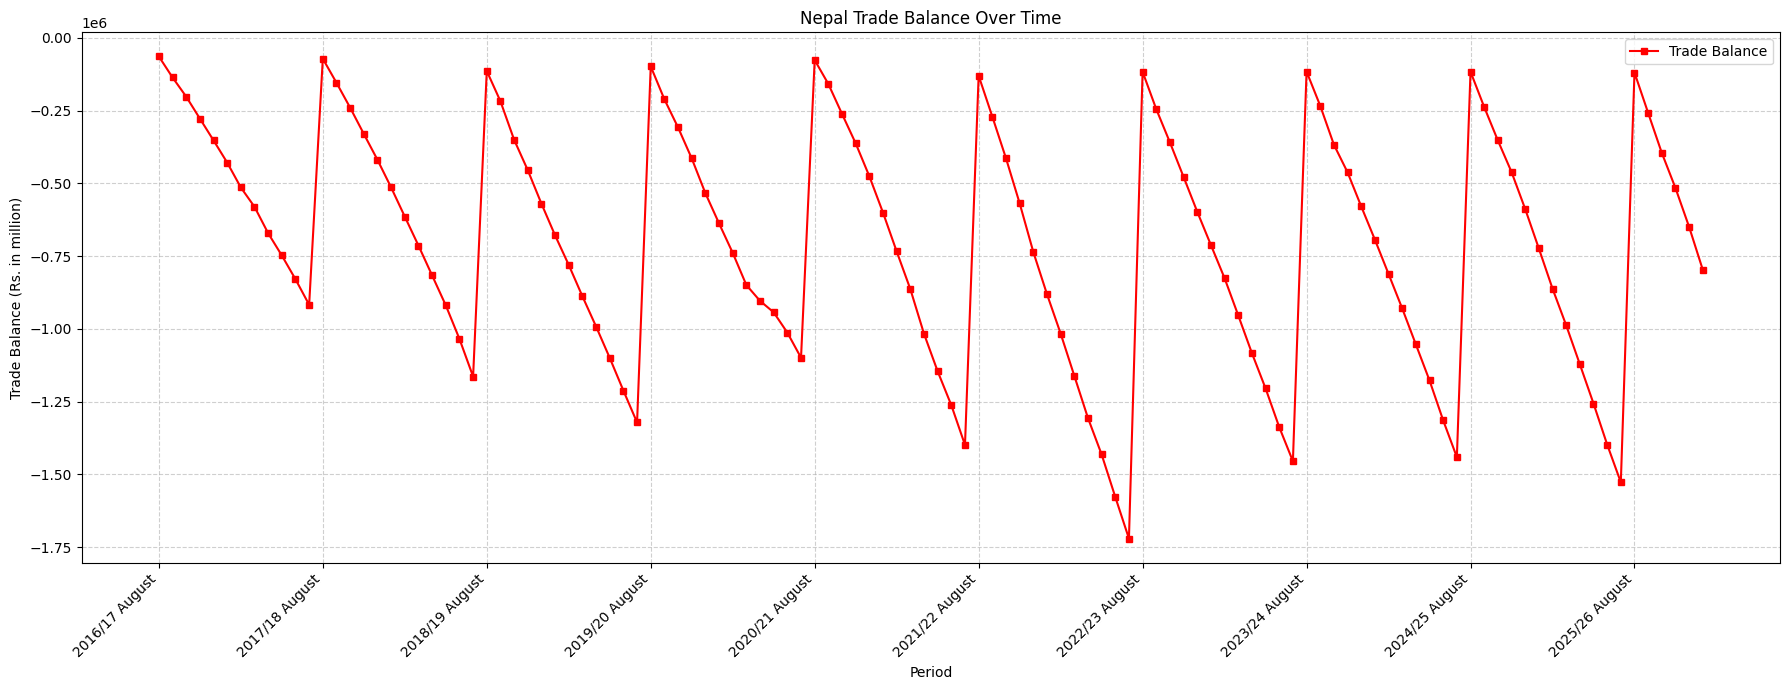

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload df_trade and ensure preprocessing is applied within this cell
df_trade = pd.read_excel(xl, sheet_name='A9.Foreign Trade', skiprows=4)
df_trade = df_trade.dropna(how='all')

# Rename columns for clarity based on the header inspection
df_trade = df_trade.rename(columns={
    'Unnamed: 1': 'Fiscal Year',
    'Unnamed: 2': 'Mid-Month',
    'Amount': 'Total Exports',
    'Amount.1': 'Total Imports'
})

# Drop the 'Unnamed: 0' column as it contains only NaN values
df_trade = df_trade.drop(columns=['Unnamed: 0'])

# Forward fill Fiscal Year and Mid-Month
df_trade['Fiscal Year'] = df_trade['Fiscal Year'].ffill()
df_trade['Mid-Month'] = df_trade['Mid-Month'].ffill()

# Combine Fiscal Year + Month into one readable label
df_trade['Period'] = df_trade['Fiscal Year'].astype(str) + ' ' + df_trade['Mid-Month'].astype(str)

# Calculate Trade Balance
df_trade['Trade Balance'] = df_trade['Total Exports'] - df_trade['Total Imports']

plt.figure(figsize=(18, 7))
plt.plot(df_trade['Period'], df_trade['Trade Balance'], label='Trade Balance', color='red', marker='s', markersize=4)

# Show only every 12th label to prevent overlap
plt.xticks(range(0, len(df_trade), 12), df_trade['Period'][::12], rotation=45, ha='right')

plt.title('Nepal Trade Balance Over Time')
plt.xlabel('Period')
plt.ylabel('Trade Balance (Rs. in million)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

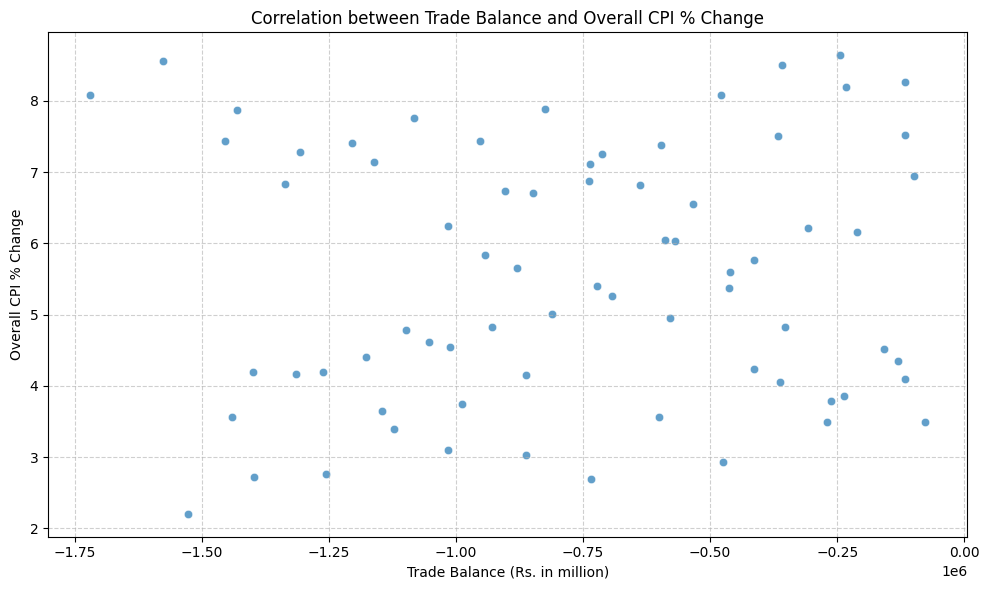

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_merged['Trade Balance'], y=df_merged['% Change'], alpha=0.7)
plt.title('Correlation between Trade Balance and Overall CPI % Change')
plt.xlabel('Trade Balance (Rs. in million)')
plt.ylabel('Overall CPI % Change')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

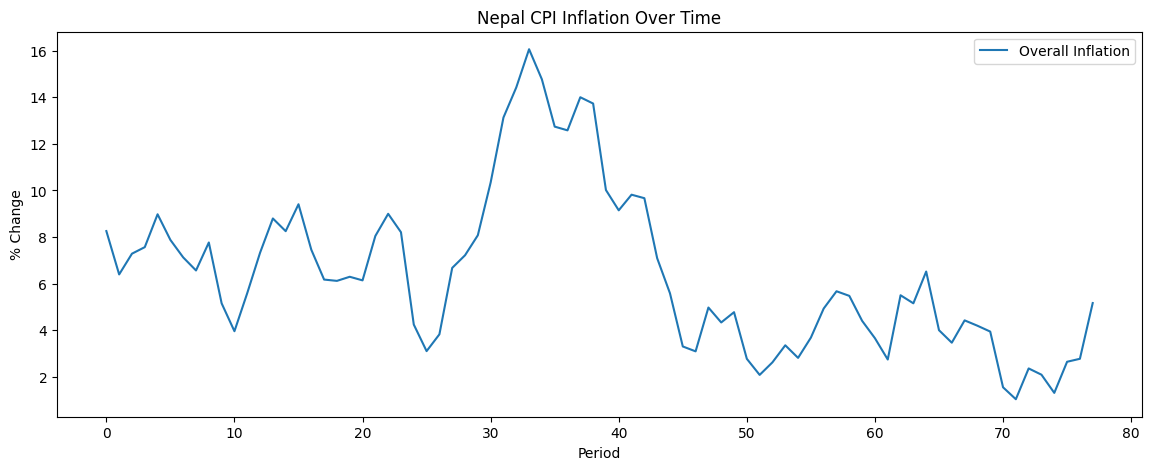

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_cpi['% Change.3'], label='Overall Inflation')
plt.title('Nepal CPI Inflation Over Time')
plt.xlabel('Period')
plt.ylabel('% Change')
plt.legend()
plt.show()

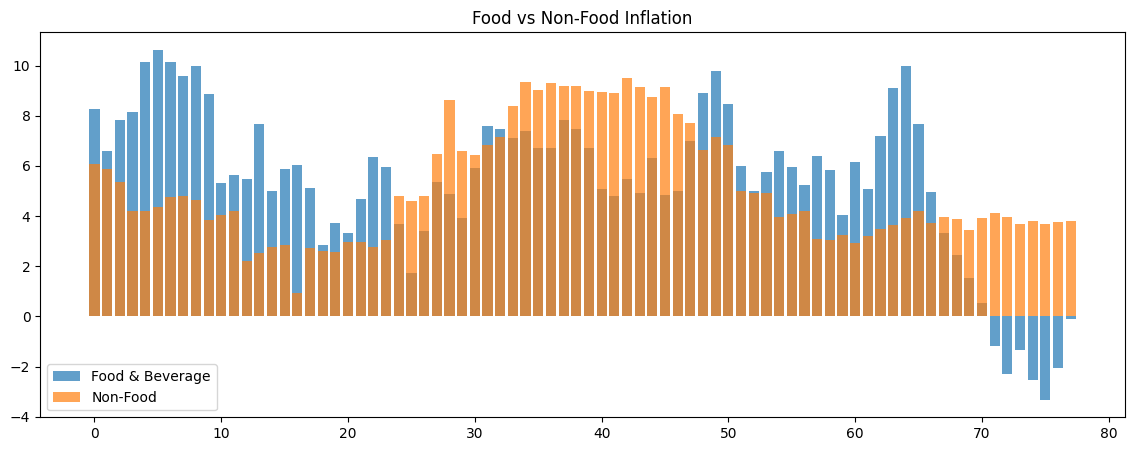

In [9]:
plt.figure(figsize=(14, 5))
plt.bar(range(len(df_cpi)), df_cpi['% Change.1'], label='Food & Beverage', alpha=0.7)
plt.bar(range(len(df_cpi)), df_cpi['% Change.2'], label='Non-Food', alpha=0.7)
plt.title('Food vs Non-Food Inflation')
plt.legend()
plt.show()

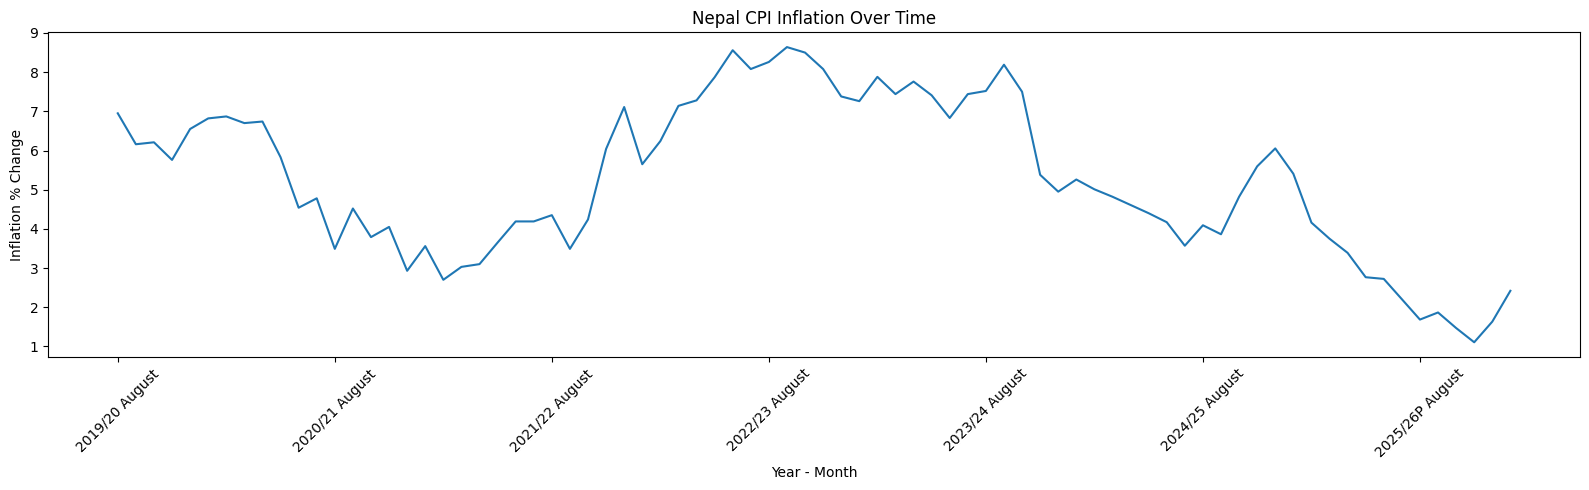

In [10]:
# Combine Fiscal Year + Month into one readable label
df_cpi['Period'] = df_cpi['Unnamed: 0'].astype(str) + ' ' + df_cpi['Unnamed: 1'].astype(str)

# Now plot with real labels
plt.figure(figsize=(16, 5))
plt.plot(df_cpi['Period'], df_cpi['% Change'])

# Show only every 12th label so they don't overlap
plt.xticks(range(0, len(df_cpi), 12), df_cpi['Period'][::12], rotation=45)

plt.title('Nepal CPI Inflation Over Time')
plt.xlabel('Year - Month')
plt.ylabel('Inflation % Change')
plt.tight_layout()
plt.show()

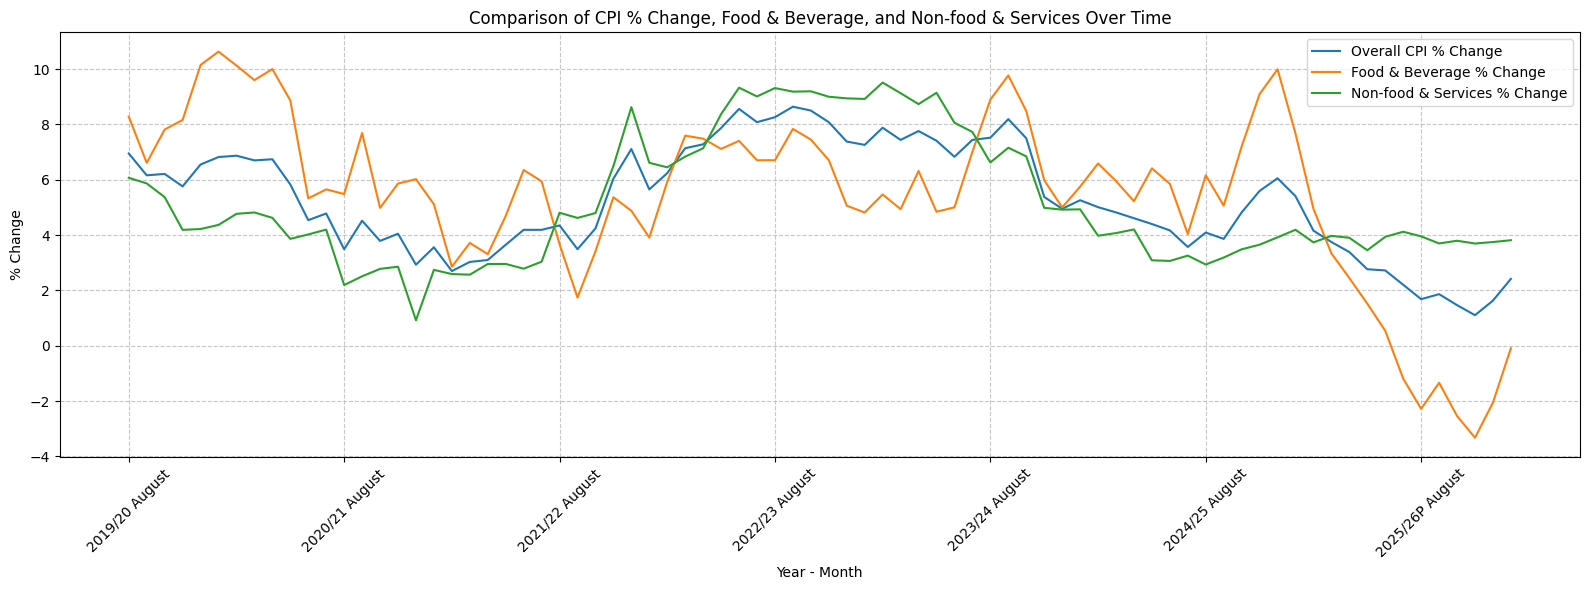

In [11]:
plt.figure(figsize=(16, 6))
plt.plot(df_cpi['Period'], df_cpi['% Change'], label='Overall CPI % Change')
plt.plot(df_cpi['Period'], df_cpi['% Change.1'], label='Food & Beverage % Change')
plt.plot(df_cpi['Period'], df_cpi['% Change.2'], label='Non-food & Services % Change')

# Show only every 12th label so they don't overlap
plt.xticks(range(0, len(df_cpi), 12), df_cpi['Period'][::12], rotation=45)

plt.title('Comparison of CPI % Change, Food & Beverage, and Non-food & Services Over Time')
plt.xlabel('Year - Month')
plt.ylabel('% Change')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()